In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU

import math

In [4]:
import pandas as pd

df = pd.read_csv("C:/Users/abhis/Downloads/monthly_milk_production.csv")
print(df.columns)
df.head()

Index(['Date', 'Production'], dtype='object')


,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [5]:
df['Date'] = pd.to_datetime(df['Date'])

df.set_index('Date', inplace=True)

print(df.head())
print(df.info())

            Production
Date                  
1962-01-01         589
1962-02-01         561
1962-03-01         640
1962-04-01         656
1962-05-01         727
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 1962-01-01 to 1975-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Production  168 non-null    int64
dtypes: int64(1)
memory usage: 2.6 KB
None


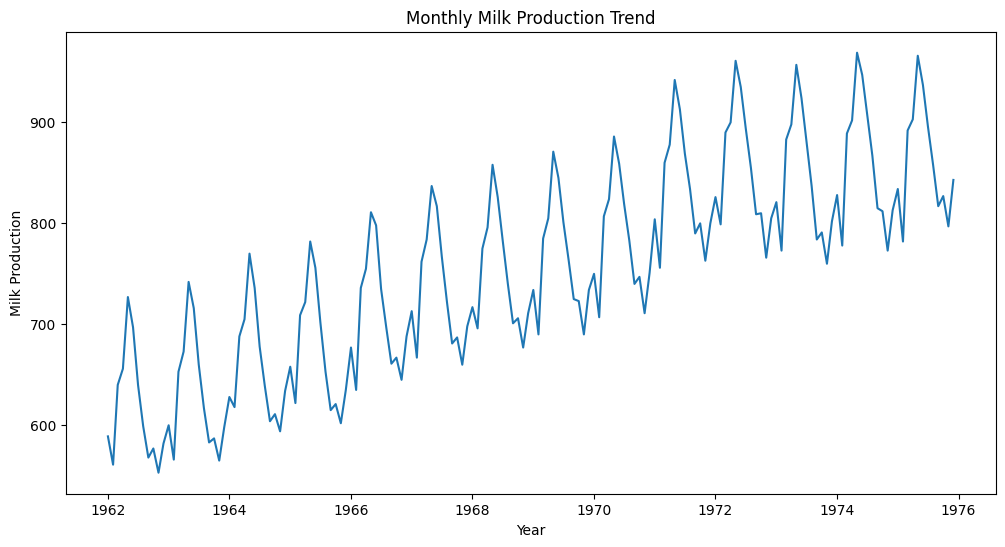

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df['Production'])

plt.title("Monthly Milk Production Trend")

plt.xlabel("Year")

plt.ylabel("Milk Production")

plt.show()

In [7]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(df[['Production']])

print(scaled_data[:5])

[[0.08653846]
 [0.01923077]
 [0.20913462]
 [0.24759615]
 [0.41826923]]


In [8]:
import numpy as np

def create_dataset(dataset, time_step=12):

    X, y = [], []

    for i in range(len(dataset)-time_step):

        X.append(dataset[i:(i+time_step), 0])
        y.append(dataset[i + time_step, 0])

    return np.array(X), np.array(y)

time_step = 12

X, y = create_dataset(scaled_data, time_step)

print(X.shape)
print(y.shape)

(156, 12)
(156,)


In [9]:
print(X.shape)
print(y.shape)

(156, 12)
(156,)


In [10]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test  = X[train_size:]

y_train = y[:train_size]
y_test  = y[train_size:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (124, 12)
Test shape: (32, 12)


In [11]:
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("Reshaped X_train:", X_train.shape)
print("Reshaped X_test:", X_test.shape)

Reshaped X_train: (124, 12, 1)
Reshaped X_test: (32, 12, 1)


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

rnn_model = Sequential()

rnn_model.add(
    SimpleRNN(
        units=50,
        activation='tanh',
        input_shape=(12,1)
    )
)

rnn_model.add(Dense(1))

rnn_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    verbose=1
)

C:\Users\abhis\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0416
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0132 
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0086 
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0055 
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0043 
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0031
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0029 
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0028 
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0026 
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0026     
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0025 
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0024 
Epoch 13/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0023 
Epoch 14/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0023 
Epoch 15/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0022 
Epoch 16/50
8/8 ━━━━━━━━━━━━━━━

In [13]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential()

lstm_model.add(
    LSTM(
        units=50,
        activation='tanh',
        input_shape=(12,1)
    )
)

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.2559
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0801 
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0332 
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0337  
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0287
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0293 
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0266 
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0267 
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0262
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0266 
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0255 
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0250  
Epoch 13/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0245 
Epoch 14/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0242 
Epoch 15/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0239 
Epoch 16/50
8/8 ━━━━━━━━━━━━━━━

In [14]:
from tensorflow.keras.layers import GRU

gru_model = Sequential()

gru_model.add(
    GRU(
        units=50,
        activation='tanh',
        input_shape=(12,1)
    )
)

gru_model.add(Dense(1))

gru_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.1841
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0569 
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0295 
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0333
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0265  
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0260
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0245
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0238 
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0232 
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0225 
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0218
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0213 
Epoch 13/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0207
Epoch 14/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0204 
Epoch 15/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0196
Epoch 16/50
8/8 ━━━━━━━━━━━━━━━━━━

In [15]:
rnn_pred = rnn_model.predict(X_test)
lstm_pred = lstm_model.predict(X_test)
gru_pred = gru_model.predict(X_test)


rnn_pred = scaler.inverse_transform(
    rnn_pred.reshape(-1,1)
)

lstm_pred = scaler.inverse_transform(
    lstm_pred.reshape(-1,1)
)

gru_pred = scaler.inverse_transform(
    gru_pred.reshape(-1,1)
)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

print("Prediction Done")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step
Prediction Done


In [16]:
import math
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

def evaluate(actual, predicted, name):

    rmse = math.sqrt(
        mean_squared_error(actual, predicted)
    )

    mae = mean_absolute_error(
        actual, predicted
    )

    mape = np.mean(
        np.abs(
            (actual - predicted) / actual
        )
    ) * 100

    print(f"\n{name} Results")
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("MAPE:", mape)

evaluate(y_test_actual, rnn_pred, "RNN")
evaluate(y_test_actual, lstm_pred, "LSTM")
evaluate(y_test_actual, gru_pred, "GRU")


RNN Results
RMSE: 17.536130564494925
MAE: 13.84540748596191
MAPE: 1.6616119465239005

LSTM Results
RMSE: 26.983540921907412
MAE: 20.68470001220702
MAPE: 2.4631023934422442

GRU Results
RMSE: 30.670809636344025
MAE: 25.6665859222412
MAPE: 3.0132019012317683


In [18]:
future_steps = 12

last_data = scaled_data[-12:]

future_input = last_data.reshape(1, 12, 1)

future_output = []

for i in range(future_steps):

    pred = rnn_model.predict(
        future_input,
        verbose=0
    )

    future_output.append(pred[0][0])

    # FIXED reshaping
    pred_reshaped = pred.reshape(1,1,1)

    future_input = np.concatenate(
        (future_input[:,1:,:],
         pred_reshaped),
        axis=1
    )

future_output = scaler.inverse_transform(
    np.array(future_output).reshape(-1,1)
)

print("Next 12 Months Forecast:")
print(future_output)

Next 12 Months Forecast:
[[843.79205]
 [816.8935 ]
 [885.6126 ]
 [899.1238 ]
 [955.0011 ]
 [939.26953]
 [908.1838 ]
 [877.5906 ]
 [832.42957]
 [845.2382 ]
 [820.645  ]
 [844.8159 ]]


C:\Users\abhis\AppData\Local\Temp\ipykernel_17368\918869785.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


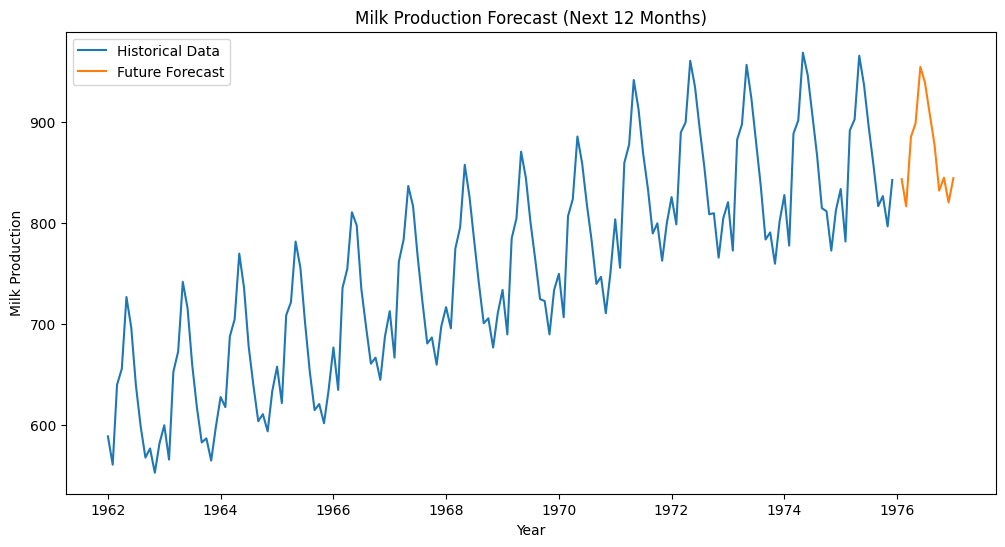

In [19]:
plt.figure(figsize=(12,6))

plt.plot(
    df.index,
    df['Production'],
    label="Historical Data"
)

future_dates = pd.date_range(
    start=df.index[-1],
    periods=13,
    freq='M'
)[1:]

plt.plot(
    future_dates,
    future_output,
    label="Future Forecast"
)

plt.title("Milk Production Forecast (Next 12 Months)")

plt.xlabel("Year")

plt.ylabel("Milk Production")

plt.legend()

plt.show()

This project focuses on forecasting monthly milk production using deep learning models such as Recurrent Neural Network (RNN), Long Short-Term Memory (LSTM), and Gated Recurrent Unit (GRU). The dataset containing historical monthly milk production values was analyzed to identify seasonal patterns and trends. Data preprocessing techniques such as normalization and sequence generation were applied to prepare the dataset for time-series forecasting. Three deep learning models were developed and evaluated using RMSE, MAE, and MAPE metrics. Among the models, the RNN model demonstrated the best performance with the lowest prediction errors. The final model was used to forecast milk production for the next 12 months. These forecasts can support better decision-making in supply chain management, inventory planning, and operational efficiency.

Time-series forecasting plays a crucial role in many industries, especially in agriculture and dairy production. Accurate prediction of milk production helps businesses manage supply chain operations, storage capacity, and workforce allocation efficiently. With the advancement of deep learning techniques, models such as RNN, LSTM, and GRU have proven effective in capturing sequential patterns in time-series data.

This project aims to develop deep learning models to forecast monthly milk production using historical data. By analyzing patterns such as seasonality and trends, the models can generate reliable predictions for future months. The results obtained from this study help demonstrate the effectiveness of deep learning techniques in real-world forecasting problems.

METHODOLOGY
Data Collection

The dataset used in this project contains historical monthly milk production records. The dataset includes date-wise production values representing milk output over several years.

Data Preprocessing

The date column was converted into datetime format and set as the index. The dataset was normalized using MinMaxScaler to improve model performance. A sliding window technique with a time step of 12 months was used to create input-output sequences suitable for time-series forecasting.

Model Development

Three deep learning models were developed:

Recurrent Neural Network (RNN)
Long Short-Term Memory (LSTM)
Gated Recurrent Unit (GRU)

Each model was trained using 80% of the dataset, while the remaining 20% was used for testing. The models were trained using the Adam optimizer and mean squared error loss function.

Model Evaluation

The performance of the models was evaluated using:

Root Mean Square Error (RMSE)
Mean Absolute Error (MAE)
Mean Absolute Percentage Error (MAPE)

The results were compared to identify the most accurate model.

The performance of the developed models is summarized below:

| Model | RMSE  | MAE   | MAPE  |
| ----- | ----- | ----- | ----- |
| RNN   | 17.54 | 13.85 | 1.66% |
| LSTM  | 26.98 | 20.68 | 2.46% |
| GRU   | 30.67 | 25.67 | 3.01% |


Among the three models, the RNN model achieved the lowest RMSE, MAE, and MAPE values, indicating superior performance. The models successfully captured seasonal patterns and long-term trends in the milk production data.

The prediction plots showed that the forecasted values closely followed the actual production values, demonstrating the effectiveness of the selected model.

The forecasting results provide valuable insights for dairy production planning. The predicted monthly milk production can help businesses optimize storage capacity and manage supply chain logistics more efficiently. Workforce planning can also be improved by estimating expected production levels in advance.

The seasonal trends observed in the data indicate that milk production varies across months, making forecasting an essential tool for minimizing wastage and ensuring consistent supply. By using accurate forecasts, dairy businesses can enhance operational efficiency and improve profitability.

This project successfully implemented RNN, LSTM, and GRU models for forecasting monthly milk production. The dataset was preprocessed and transformed into suitable sequences for training deep learning models. Among the three models, the RNN model demonstrated the best performance based on evaluation metrics.

The final forecasting results provide reliable predictions for future milk production, which can support effective planning and decision-making in dairy operations. This study highlights the usefulness of deep learning techniques in time-series forecasting tasks.